# Build your own separation manager

Every encounter is kept safe by a **separation manager** that runs three pluggable strategies each decision step:

1. **Conflict detection** (CD) — *will these two lose separation?*
2. **Conflict resolution** (CR) — *if so, what velocity avoids it?*
3. **Recovery** (CRR) — *when is it safe to stop avoiding and return to the mission?*

The defaults are **`StateBased`**, **`MVP`**, and **`PastCPA`**. Each is an abstract base class with a single method — so to build your own you subclass it, implement that one method, and pass the instance to `run_fleet`. Nothing else (the loop, the fleet, the other two strategies) changes.

This notebook builds a deliberately simple custom version of each and swaps it in **one at a time**, leaving the other two at their defaults.

| stage | base class | method to implement | returns |
|---|---|---|---|
| detection | `ConflictDetector` | `detect(own, intr, rpz, t_lookahead)` | `bool` |
| resolution | `ConflictResolver` | `resolve(own, intruders, rpz, preferred)` | `MotionCommand` |
| recovery | `RecoveryCriterion` | `should_resume(own, intr, rpz)` | `bool` |

All three are **directed** (from ownship's point of view) and **pure** (a function of their arguments only — no stored mutable state), which is what keeps a run reproducible.

In [1]:
# Install once (from the repo root, in a terminal):  pip install -e ".[examples]"
# %pip install -e "..[examples]"

## Setup and the default baseline

The same pairwise crossing as the first notebook: a multirotor cruising north, a fixed-wing placed to cross it. `run(**overrides)` runs it with the defaults (`StateBased`, `MVP`, `PastCPA`) unless you override one — so each section below changes exactly one strategy.

default: min_sep = 59.6 m,  los = False


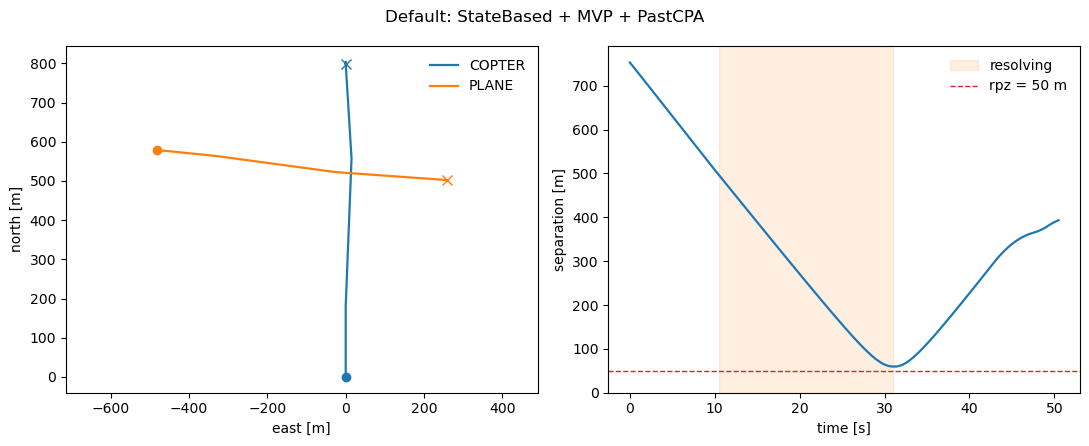

In [2]:
%matplotlib inline
from collections.abc import Sequence

from opencdarr.fleet import Agent, run_fleet
from opencdarr.dynamics import FixedWing, Multirotor, MotionCommand
from opencdarr.performance import M600, SMALL_FIXEDWING
from opencdarr.autopilot import WaypointAutopilot
from opencdarr.mission import Mission
from opencdarr.scenario import create_conflict
from opencdarr.state import AircraftState
from opencdarr import geo
from opencdarr.kinematics import velocity_enu, relative_enu
from opencdarr.viz import plot_pairwise

# the defaults, and their base classes (subclass these to build your own)
from opencdarr.cd import StateBased
from opencdarr.cd.base import ConflictDetector
from opencdarr.cr import MVP
from opencdarr.cr.base import ConflictResolver
from opencdarr.crr import PastCPA
from opencdarr.crr.base import RecoveryCriterion

copter = AircraftState(id='COPTER', lat=52.0, lon=4.0, trk=0.0, gs=18.0, yaw=0.0)
plane = create_conflict(copter, intr_id='PLANE', dpsi=90.0, dcpa=0.0,
                        tlos=30.0, rpz=50.0, gs_intr=15.0, side=1)
agents = [
    Agent(copter, M600, Multirotor(),
          WaypointAutopilot(Mission(goto=geo.forward(copter.lat, copter.lon, copter.trk, 800.0)))),
    Agent(plane, SMALL_FIXEDWING, FixedWing(),
          WaypointAutopilot(Mission(goto=geo.forward(plane.lat, plane.lon, plane.trk, 800.0)),
                            cruise_airspeed=15.0)),
]

def run(**overrides):
    """Run the crossing with the default CD/CR/CRR unless an override is given."""
    cfg = dict(
        detector=StateBased(), resolver=MVP(), recovery=PastCPA(bouncing_guard=True),
        rpz=50.0, t_lookahead=20.0, dt=0.5, stop_within=100.0, done_timeout=60.0, record=True,
    )
    cfg.update(overrides)
    return run_fleet(agents, **cfg)

base = run()  # StateBased + MVP + PastCPA
print(f'default: min_sep = {base.min_sep:.1f} m,  los = {base.los}')
fig = plot_pairwise(base, rpz=50.0, title='Default: StateBased + MVP + PastCPA')

## 1. Your own conflict **detection**

`detect` answers one yes/no question per directed pair and returns a `bool`. The default `StateBased` is *predictive*: it projects the closest approach and flags a conflict if it falls inside `rpz` within `t_lookahead`.

Here is a dummy that ignores the prediction entirely — it flags a conflict purely on **current distance**: closer than 100 m ⇒ conflict.

ProximityDetect(100 m): min_sep = 50.0 m,  los = True


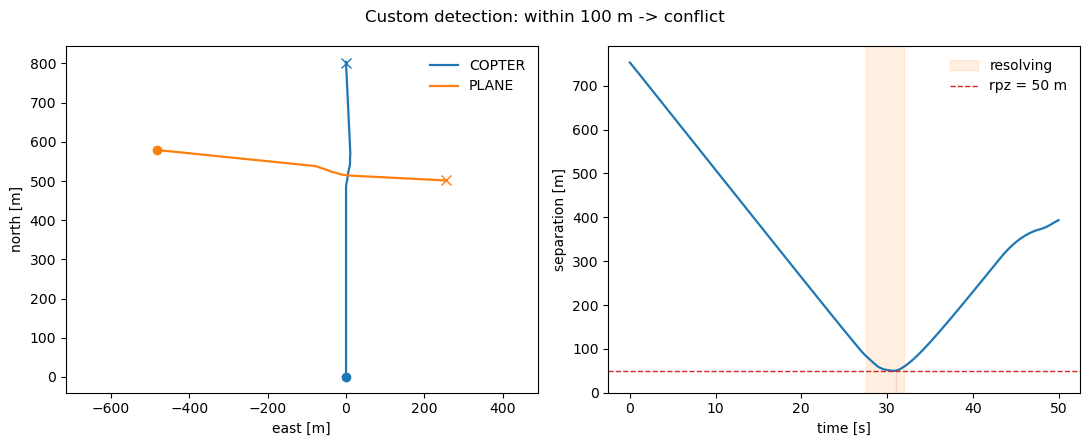

In [3]:
class ProximityDetect(ConflictDetector):
    """Flag a conflict when the intruder is currently within `trigger` metres."""

    def __init__(self, trigger: float = 100.0) -> None:
        self.trigger = trigger

    def detect(self, own: AircraftState, intr: AircraftState,
               rpz: float, t_lookahead: float) -> bool:
        _, dist = geo.qdrdist(own.lat, own.lon, intr.lat, intr.lon)
        return dist <= self.trigger   # reactive: ignores t_lookahead

out = run(detector=ProximityDetect(100.0))   # <- only the detector changes; CR/CRR stay default
print(f'ProximityDetect(100 m): min_sep = {out.min_sep:.1f} m,  los = {out.los}')
fig = plot_pairwise(out, rpz=50.0, title='Custom detection: within 100 m -> conflict')

Because it only reacts once the aircraft are *already* within 100 m — rather than predicting the crossing — the resolver kicks in late and separation is squeezed right down to (or below) the `rpz`. That contrast with the predictive default is the whole point of a swappable detector: the same resolver behaves very differently depending on *when* it is told to act.

## 2. Your own conflict **resolution**

`resolve` returns a `MotionCommand` carrying a ground-velocity vector (`target_velocity=(v_east, v_north)`) that flows straight into the dynamics. It receives the **set** of intruders in conflict (length 1 for a pairwise encounter). The default `MVP` nudges the velocity along a potential-field gradient; ours is blunter — hold course until an intruder is within 70 m, then hard-turn 90° to the right.

CloseRangeAvoid(70 m): min_sep = 39.4 m,  los = True


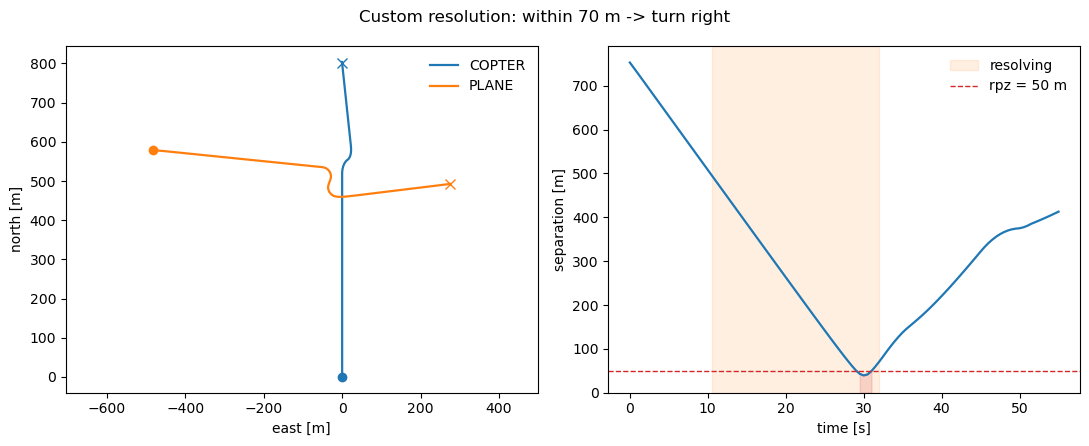

In [4]:
class CloseRangeAvoid(ConflictResolver):
    """Hold course until an intruder is within `trigger` m, then turn 90 deg right."""

    def __init__(self, trigger: float = 70.0) -> None:
        self.trigger = trigger

    def resolve(self, own: AircraftState, intruders: Sequence[AircraftState],
                rpz: float, preferred: tuple[float, float] | None = None) -> MotionCommand:
        v_east, v_north = velocity_enu(own)   # own's current ground velocity
        nearest = min((relative_enu(own, i).dist for i in intruders), default=float('inf'))
        if nearest <= self.trigger:
            return MotionCommand(target_velocity=(v_north, -v_east))  # 90 deg right, same speed
        return MotionCommand(target_velocity=(v_east, v_north))       # else: unchanged

out = run(resolver=CloseRangeAvoid(70.0))     # <- only the resolver changes
print(f'CloseRangeAvoid(70 m): min_sep = {out.min_sep:.1f} m,  los = {out.los}')
fig = plot_pairwise(out, rpz=50.0, title='Custom resolution: within 70 m -> turn right')

The right-angle track kink is your resolver firing. It is deliberately crude — a fixed turn at a fixed range takes no account of the geometry — so it clears less room than `MVP` and can dip below `rpz`. Swap in your own velocity rule on the `if` branch: slow down (`(0.0, 0.0)`), speed up, or compute a smarter vector from `relative_enu(own, i)`.

## 3. Your own **recovery** criterion

Once a resolver is steering, recovery decides *when to stop* and let the aircraft return to its mission — `should_resume` returns `True` to hand control back to the autopilot. The default `PastCPA` resumes once the pair is past its closest point and separating. Ours is simpler: resume as soon as the two are more than 120 m apart.

RangeClear(120 m): min_sep = 55.5 m,  los = False


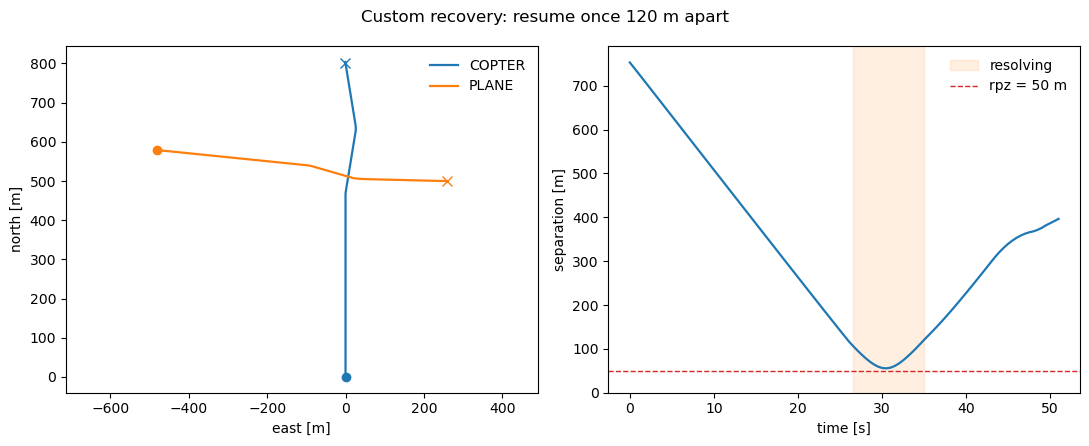

In [5]:
class RangeClear(RecoveryCriterion):
    """Resume the mission once the intruder is at least `resume_dist` metres away."""

    def __init__(self, resume_dist: float = 120.0) -> None:
        self.resume_dist = resume_dist

    def should_resume(self, own: AircraftState, intr: AircraftState, rpz: float) -> bool:
        _, dist = geo.qdrdist(own.lat, own.lon, intr.lat, intr.lon)
        return dist >= self.resume_dist

out = run(recovery=RangeClear(120.0))         # <- only the recovery changes
print(f'RangeClear(120 m): min_sep = {out.min_sep:.1f} m,  los = {out.los}')
fig = plot_pairwise(out, rpz=50.0, title='Custom recovery: resume once 120 m apart')

The orange band (when an aircraft is resolving) now ends the moment the pair passes 120 m of separation, and each aircraft turns back toward its waypoint. A distance threshold that is too eager can resume while the aircraft are still closing and re-trigger the conflict — a *bounce* — which is exactly the failure `PastCPA`'s `bouncing_guard` exists to prevent.

## 4. All three at once

Because each is an independent plug, you can swap all three together — a fully custom separation manager in three small classes:

all custom: min_sep = 39.4 m,  los = True


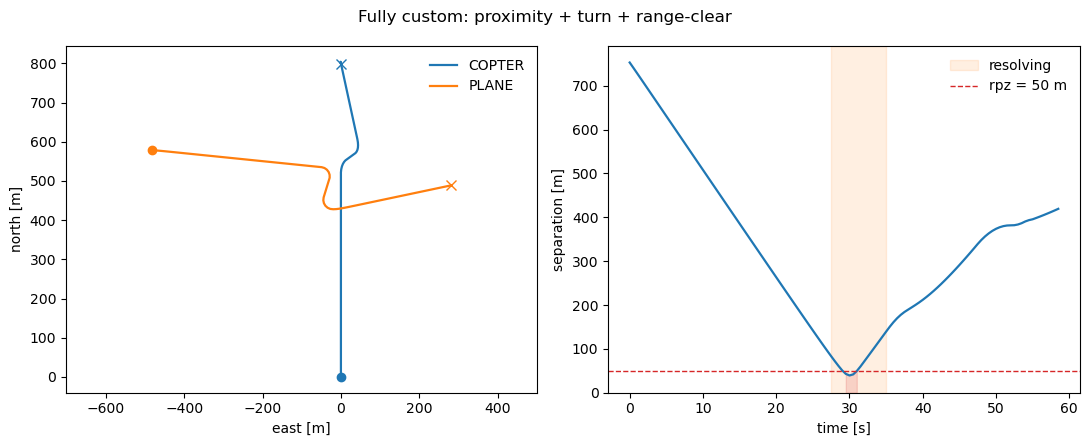

In [6]:
out = run(detector=ProximityDetect(100.0),
          resolver=CloseRangeAvoid(70.0),
          recovery=RangeClear(120.0))
print(f'all custom: min_sep = {out.min_sep:.1f} m,  los = {out.los}')
fig = plot_pairwise(out, rpz=50.0, title='Fully custom: proximity + turn + range-clear')

## 5. Combining resolution and recovery in one object

Resolution and recovery are two sides of the same question — *are we still too close?* — so it is natural to want them in **one place**. A note on how far that can go: the separation manager calls `recovery.should_resume(...)` and `resolver.resolve(...)` at *two different points* of each step (recovery first prunes the active-conflict set, then the resolver acts on what remains), so you can't fuse them into a single function *call*. But you can put both in **one class** that shares a single rule, and pass that same object as *both* `resolver` and `recovery`.

Here the shared rule is one helper, `_too_close`: recovery resumes exactly when it is false, and resolution steers directly away from the nearest intruder while it is true.

ReactiveAvoider(90 m): min_sep = 50.8 m,  los = False


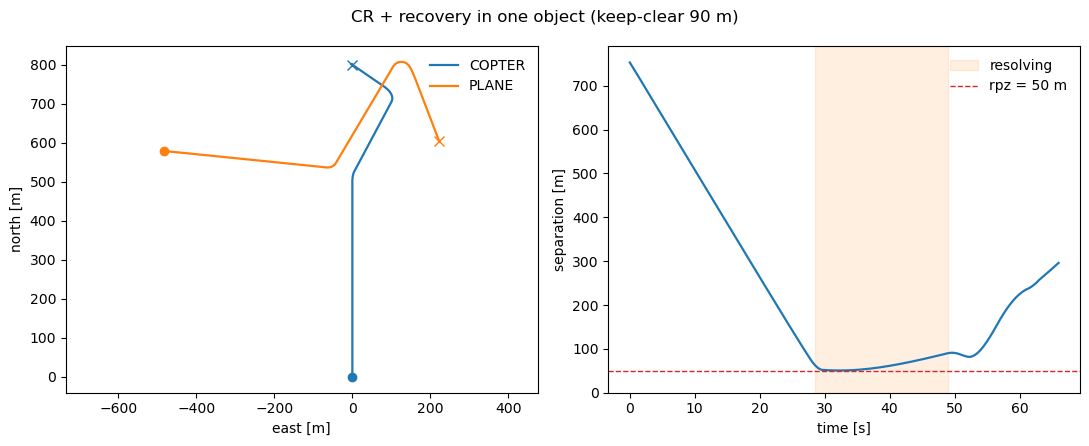

In [7]:
import math

class ReactiveAvoider(ConflictResolver, RecoveryCriterion):
    """CR + CRR in one object, sharing a single keep-clear range."""

    def __init__(self, keep_clear: float = 90.0) -> None:
        self.keep_clear = keep_clear   # avoid while within this range; resume once beyond it

    def _too_close(self, own: AircraftState, intr: AircraftState) -> bool:
        _, dist = geo.qdrdist(own.lat, own.lon, intr.lat, intr.lon)
        return dist < self.keep_clear   # the one rule both faces share

    def should_resume(self, own: AircraftState, intr: AircraftState, rpz: float) -> bool:
        return not self._too_close(own, intr)          # recovery: resume once clear

    def resolve(self, own: AircraftState, intruders: Sequence[AircraftState],
                rpz: float, preferred: tuple[float, float] | None = None) -> MotionCommand:
        v_east, v_north = velocity_enu(own)
        speed = math.hypot(v_east, v_north)
        nearest = min(intruders, key=lambda i: relative_enu(own, i).dist)
        rel = relative_enu(own, nearest)               # rel.rx, rel.ry point own -> intruder
        return MotionCommand(target_velocity=(-rel.rx / rel.dist * speed,   # steer directly
                                              -rel.ry / rel.dist * speed))  # away, same speed

avoider = ReactiveAvoider(90.0)
out = run(resolver=avoider, recovery=avoider)   # <- the same object serves both roles
print(f'ReactiveAvoider(90 m): min_sep = {out.min_sep:.1f} m,  los = {out.los}')
fig = plot_pairwise(out, rpz=50.0, title='CR + recovery in one object (keep-clear 90 m)')

One class, one shared threshold, passed twice. The aircraft flee whenever a neighbour is inside 90 m and turn back to the mission the instant it is beyond — and because both decisions read the *same* `_too_close`, they can never disagree. Note it uses the default `StateBased` detector: the resolver only ever runs for conflicts the detector raises, so a combined CR/CRR object still relies on detection to wake it up.

(If you truly wanted a *single* method returning both the command and the resume flag, that would mean changing the `SeparationManager` itself — a framework change, not a plug-in.)

## 6. Detection + resolution in one object

The same trick joins the first two stages. `ProximityAvoider` both **detects** (within 100 m) and **resolves** (steer directly away from the nearest intruder); recovery stays the default `PastCPA`. Detection and resolution now share the same reactive philosophy in one class.

ProximityAvoider(100 m): min_sep = 68.1 m,  los = False


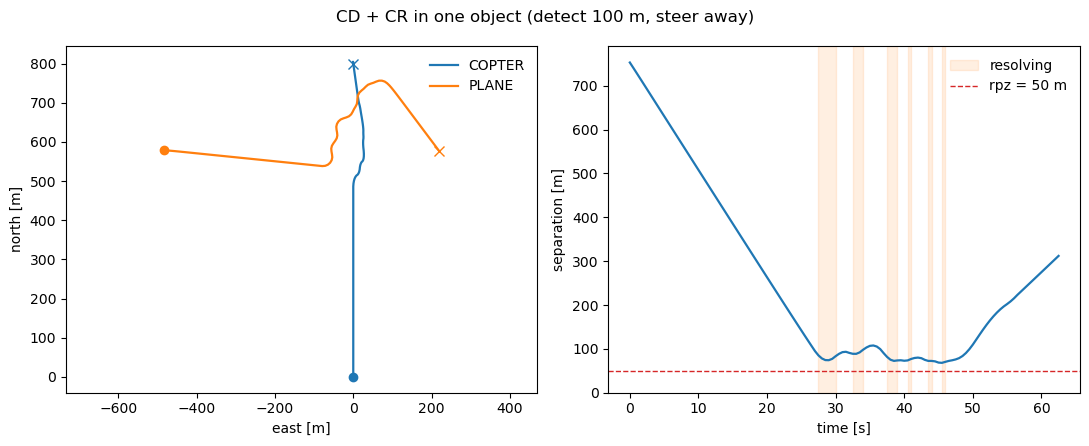

In [8]:
class ProximityAvoider(ConflictDetector, ConflictResolver):
    """CD + CR in one: flag a conflict within `trigger` m, and steer directly away."""

    def __init__(self, trigger: float = 100.0) -> None:
        self.trigger = trigger

    def detect(self, own: AircraftState, intr: AircraftState,
               rpz: float, t_lookahead: float) -> bool:
        _, dist = geo.qdrdist(own.lat, own.lon, intr.lat, intr.lon)
        return dist <= self.trigger

    def resolve(self, own: AircraftState, intruders: Sequence[AircraftState],
                rpz: float, preferred: tuple[float, float] | None = None) -> MotionCommand:
        v_east, v_north = velocity_enu(own)
        speed = math.hypot(v_east, v_north)
        rel = relative_enu(own, min(intruders, key=lambda i: relative_enu(own, i).dist))
        return MotionCommand(target_velocity=(-rel.rx / rel.dist * speed,
                                              -rel.ry / rel.dist * speed))

pa = ProximityAvoider(100.0)
out = run(detector=pa, resolver=pa)   # one object is BOTH detector and resolver; recovery default
print(f'ProximityAvoider(100 m): min_sep = {out.min_sep:.1f} m,  los = {out.los}')
fig = plot_pairwise(out, rpz=50.0, title='CD + CR in one object (detect 100 m, steer away)')

Detection wakes the resolver at 100 m, the steer-away opens the range, and the default `PastCPA` decides when to head back — the pair stays clear of the 50 m zone.

## 7. A whole separation manager in one object

Add detection to the combined resolver/recovery and one class covers **all three** stages — a self-contained reactive CD&R governed by a single number, `react_range`: a conflict is on while a neighbour is inside it, resolution steers away, and recovery resumes once outside it. It no longer needs `StateBased` at all — it is its own detector.

ReactiveManager(120 m): min_sep = 66.8 m,  los = False


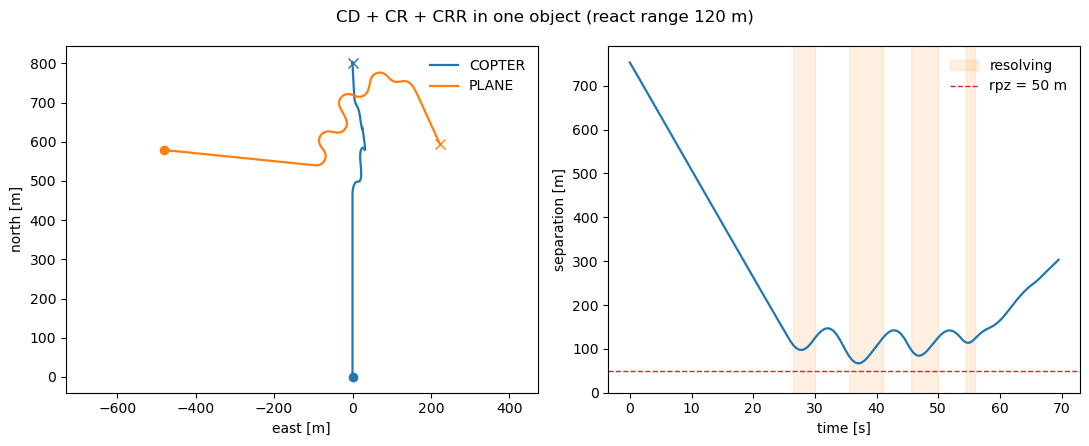

In [9]:
class ReactiveManager(ConflictDetector, ConflictResolver, RecoveryCriterion):
    """CD + CR + CRR in one, all keyed to a single reaction range."""

    def __init__(self, react_range: float = 120.0) -> None:
        self.react_range = react_range

    def _close(self, own: AircraftState, intr: AircraftState) -> bool:
        _, dist = geo.qdrdist(own.lat, own.lon, intr.lat, intr.lon)
        return dist <= self.react_range      # the one rule all three stages read

    def detect(self, own: AircraftState, intr: AircraftState,
               rpz: float, t_lookahead: float) -> bool:
        return self._close(own, intr)                    # CD: conflict while inside the range

    def should_resume(self, own: AircraftState, intr: AircraftState, rpz: float) -> bool:
        return not self._close(own, intr)                # CRR: resume once outside it

    def resolve(self, own: AircraftState, intruders: Sequence[AircraftState],
                rpz: float, preferred: tuple[float, float] | None = None) -> MotionCommand:
        v_east, v_north = velocity_enu(own)              # CR: steer directly away
        speed = math.hypot(v_east, v_north)
        rel = relative_enu(own, min(intruders, key=lambda i: relative_enu(own, i).dist))
        return MotionCommand(target_velocity=(-rel.rx / rel.dist * speed,
                                              -rel.ry / rel.dist * speed))

manager = ReactiveManager(120.0)
out = run(detector=manager, resolver=manager, recovery=manager)   # one object, all three roles
print(f'ReactiveManager(120 m): min_sep = {out.min_sep:.1f} m,  los = {out.los}')
fig = plot_pairwise(out, rpz=50.0, title='CD + CR + CRR in one object (react range 120 m)')

One class, one number, the entire safety behaviour. Two things the separation curve shows. First, the knob is safety-critical: because detection, avoidance, and recovery all fire at `react_range`, it must sit comfortably above `rpz` to react in time — 120 m clears here, but drop it to 100 m and the aircraft react too late and separation is lost. Second, notice the **chatter** — the repeated resolving bands and the sawtooth separation: detect-on and resume-off share the *exact same* boundary, so the aircraft flee at 120 m, coast back inside, re-detect, and flee again. Giving the three stages their own thresholds (a detect range wider than the resume range — hysteresis) or a predictive detector smooths that out, which is exactly why the framework keeps them as separate plugs. Combining is a convenience you opt into, not the default.

## 8. When it doesn't split into three: an end-to-end policy

Detection, resolution, and recovery are the *classical* decomposition. A **learned policy** — an RL agent or a neural network — usually doesn't think that way: it maps an observation (ownship + neighbours) straight to a command, with no separate detect / resolve / recover.

It still fits, through the resolver slot. Put the whole policy in `resolve`; make `detect` return `True` (so the manager consults the policy whenever there's traffic) and `should_resume` return `False` (so the *policy* decides when to ease off). The resolver already gets the full neighbour set, and the ownship's nominal intent rides on **`own.desired`** — so the policy has its whole observation and returns one velocity. The other two methods become stubs.

EndToEndPolicy: min_sep = 91.7 m,  los = False


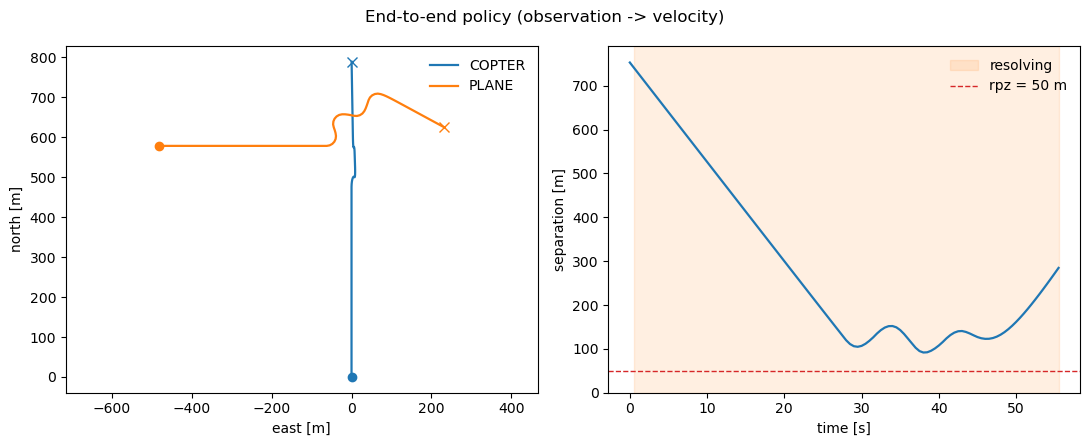

In [10]:
class EndToEndPolicy(ConflictDetector, ConflictResolver, RecoveryCriterion):
    """A monolithic policy: observation -> velocity, in one method.

    A hand rule stands in for a network here, but the shape is identical — swap the body of
    `resolve` for `model(observation)`.
    """

    def detect(self, own: AircraftState, intr: AircraftState,
               rpz: float, t_lookahead: float) -> bool:
        return True                                          # always consult the policy

    def should_resume(self, own: AircraftState, intr: AircraftState, rpz: float) -> bool:
        return False                                         # the policy owns the decision

    def resolve(self, own: AircraftState, intruders: Sequence[AircraftState],
                rpz: float, preferred: tuple[float, float] | None = None) -> MotionCommand:
        # observation = (own, intruders, own.desired);  action = a ground velocity
        rel = relative_enu(own, min(intruders, key=lambda i: relative_enu(own, i).dist))
        if rel.dist <= 120.0:                                # a network would learn this
            v_east, v_north = velocity_enu(own)
            speed = math.hypot(v_east, v_north)
            return MotionCommand(target_velocity=(-rel.rx / rel.dist * speed,
                                                  -rel.ry / rel.dist * speed))
        d = own.desired                                      # clear: fly the nominal intent
        return MotionCommand(target_velocity=(d.v_east, d.v_north))

policy = EndToEndPolicy()
out = run(detector=policy, resolver=policy, recovery=policy)
print(f'EndToEndPolicy: min_sep = {out.min_sep:.1f} m,  los = {out.los}')
fig = plot_pairwise(out, rpz=50.0, title='End-to-end policy (observation -> velocity)')

One function maps observation to command — the shape a learned controller takes. Two caveats: it still *rides* the resolver interface (the three-way split is nominally present, just ignored), and because the resolver only runs for detected conflicts, `detect` has to return `True`. The cleaner design — making the **separation manager itself** swappable, so a policy is one implementation beside the classical orchestrator — is the project's stated direction but not yet a public hook: `run_fleet` builds the classical manager internally.

## Recap

To build your own separation logic:

1. Subclass `ConflictDetector`, `ConflictResolver`, or `RecoveryCriterion`.
2. Implement the one method — return a `bool`, a `MotionCommand`, or a `bool` respectively.
3. Keep it pure (no stored mutable state between calls).
4. Pass the instance to `run_fleet(detector=…, resolver=…, recovery=…)`; anything you leave out keeps its default (`StateBased` / `MVP` / `PastCPA`).

One class can implement more than one interface and be passed to several slots — any subset you like: resolution + recovery (section 5), detection + resolution (section 6), or all three in a single object driven by one rule (section 7). The framework keeps them separate; combining is a convenience you opt into.

The dummies here are intentionally minimal — several let separation be lost — to show that each stage genuinely matters. Replace their one method with your own algorithm and everything else in the simulator stays exactly as it was.